In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df=df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

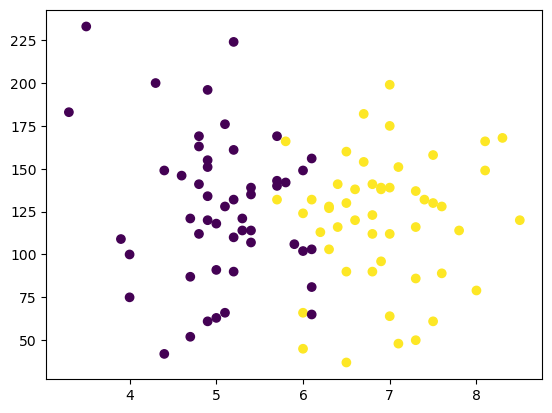

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [9]:
print(x)

    cgpa     iq
0    6.8  123.0
1    5.9  106.0
2    5.3  121.0
3    7.4  132.0
4    5.8  142.0
..   ...    ...
95   4.3  200.0
96   4.4   42.0
97   6.7  182.0
98   6.3  103.0
99   6.2  113.0

[100 rows x 2 columns]


In [10]:
print(y)

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [13]:
x_train

,cgpa,iq
12,5.4,139.0
35,6.8,90.0
61,7.3,137.0
23,4.7,87.0
8,6.1,156.0
...,...,...
13,6.4,116.0
2,5.3,121.0
70,6.3,127.0
14,6.1,103.0


In [14]:
y_train

12    0
35    1
61    1
23    0
8     0
     ..
13    1
2     0
70    1
14    0
11    1
Name: placement, Length: 90, dtype: int64

In [15]:
x_test

,cgpa,iq
18,4.0,100.0
80,4.9,196.0
43,6.8,141.0
30,7.6,128.0
3,7.4,132.0
28,5.2,90.0
24,4.7,121.0
67,5.0,118.0
90,7.3,86.0
0,6.8,123.0


In [16]:
y_test

18    0
80    0
43    1
30    1
3     1
28    0
24    0
67    0
90    1
0     1
Name: placement, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
x_train=scaler.fit_transform(x_train)

In [20]:
x_train

array([[-0.52845288,  0.37852231],
       [ 0.71845841, -0.82499851],
       [ 1.16378387,  0.32939901],
       [-1.15190852, -0.89868346],
       [ 0.09500276,  0.79607035],
       [ 1.34191405, -1.53728634],
       [ 0.45126313, -2.12676593],
       [-0.17219251,  1.04168684],
       [ 0.00593767,  0.01009757],
       [ 1.16378387, -0.18639563],
       [-0.88471325, -0.80043686],
       [ 0.00593767, -1.93027273],
       [ 0.8075235 ,  0.37852231],
       [-0.08312742, -0.43201212],
       [ 0.00593767, -0.53025872],
       [ 1.78723951, -1.09517665],
       [ 0.71845841, -0.28464223],
       [ 0.27313295, -0.50569707],
       [-0.79564815, -1.4144781 ],
       [-0.70658306,  0.91887859],
       [ 1.60910933, -0.23551893],
       [-0.2612576 ,  1.11537179],
       [-0.70658306, -0.33376552],
       [ 1.16378387, -1.80746449],
       [ 2.23256497, -0.08814903],
       [-1.4191038 , -2.00395768],
       [-2.39881981,  1.45923488],
       [ 0.89658859,  1.85222127],
       [ 0.09500276,

In [21]:
x_test = scaler.transform(x_test)

In [22]:
x_test

array([[-1.77536417, -0.57938202],
       [-0.97377834,  1.77853632],
       [ 0.71845841,  0.42764561],
       [ 1.43097914,  0.10834416],
       [ 1.25284896,  0.20659076],
       [-0.70658306, -0.82499851],
       [-1.15190852, -0.06358738],
       [-0.88471325, -0.13727233],
       [ 1.16378387, -0.92324511],
       [ 0.71845841, -0.01446408]])

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
clf=LogisticRegression()

In [25]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred=clf.predict(x_test)

In [27]:
y_pred

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 1])

In [28]:
y_test

18    0
80    0
43    1
30    1
3     1
28    0
24    0
67    0
90    1
0     1
Name: placement, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score

In [30]:
accuracy_score(y_test,y_pred)

1.0

In [37]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

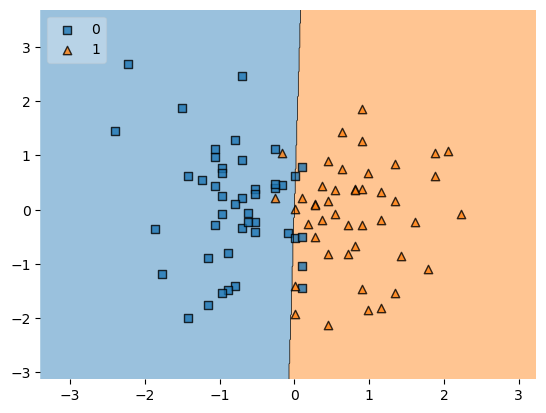

In [38]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)


In [39]:
import pickle

In [40]:
pickle.dump(clf,open('placement.pkl','wb'))